In [1]:
!pip install pyspark

In [2]:
import pyspark
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np

In [3]:
spark=SparkSession.builder \
     .appName("Pyspark Basics") \
    .getOrCreate()

In [4]:
data=spark.read.csv("/content/Stores.csv",header=True,inferSchema=True)

In [5]:
data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        1|      1659|           1961|                 530|      66490|
|        2|      1461|           1752|                 210|      39820|
|        3|      1340|           1609|                 720|      54010|
|        4|      1451|           1748|                 620|      53730|
|        5|      1770|           2111|                 450|      46620|
|        6|      1442|           1733|                 760|      45260|
|        7|      1542|           1858|                1030|      72240|
|        8|      1261|           1507|                1020|      37720|
|        9|      1090|           1321|                 680|      46310|
|       10|      1030|           1235|                1130|      44150|
|       11|      1187|           1439|                1090|     

In [6]:
data.printSchema()

root
 |-- Store ID : integer (nullable = true)
 |-- Store_Area: integer (nullable = true)
 |-- Items_Available: integer (nullable = true)
 |-- Daily_Customer_Count: integer (nullable = true)
 |-- Store_Sales: integer (nullable = true)



In [7]:
data.count()

896

In [9]:
data.describe() .show()

+-------+----------------+------------------+------------------+--------------------+------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|
+-------+----------------+------------------+------------------+--------------------+------------------+
|  count|             896|               896|               896|                 896|               896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|
|    min|               1|               775|               932|                  10|             14920|
|    max|             896|              2229|              2667|                1560|            116320|
+-------+----------------+------------------+------------------+--------------------+------------------+



In [15]:
print(data.columns)

['Store ID ', 'Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']


In [21]:
selected_data = data.select("Store ID ", "Store_Sales")

In [22]:
selected_data.show()

+---------+-----------+
|Store ID |Store_Sales|
+---------+-----------+
|        1|      66490|
|        2|      39820|
|        3|      54010|
|        4|      53730|
|        5|      46620|
|        6|      45260|
|        7|      72240|
|        8|      37720|
|        9|      46310|
|       10|      44150|
|       11|      71280|
|       12|      57620|
|       13|      60470|
|       14|      59130|
|       15|      66360|
|       16|      78870|
|       17|      77250|
|       18|      38170|
|       19|      63540|
|       20|      40190|
+---------+-----------+
only showing top 20 rows


In [23]:
filtered_data = data.filter(data["Daily_Customer_Count"]<100)

In [24]:
filtered_data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|       40|      1270|           1516|                  10|      45480|
|      152|      1662|           1986|                  70|      63730|
+---------+----------+---------------+--------------------+-----------+



In [25]:
filtered_data = data.filter(data["Daily_Customer_Count"]<500)

In [26]:
filtered_data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        2|      1461|           1752|                 210|      39820|
|        5|      1770|           2111|                 450|      46620|
|       21|      1421|           1700|                 370|      43460|
|       40|      1270|           1516|                  10|      45480|
|       53|      1074|           1288|                 320|      70450|
|       60|      1756|           2070|                 460|      53870|
|       61|      1704|           2045|                 300|      71300|
|       68|      1416|           1681|                 290|      72710|
|       77|      1267|           1520|                 450|      26770|
|       83|      1441|           1723|                 330|      57860|
|       86|      1468|           1760|                 280|     

In [27]:
filtered_data.describe().show()

+-------+------------------+------------------+------------------+--------------------+------------------+
|summary|         Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|
+-------+------------------+------------------+------------------+--------------------+------------------+
|  count|               127|               127|               127|                 127|               127|
|   mean|441.66141732283467|1503.6929133858268|1803.8346456692914|   372.4409448818898|59399.291338582676|
| stddev|252.26231058331402|231.91601900260414|278.53960887239384|    98.9204950551566|16815.498103771428|
|    min|                 2|              1009|              1202|                  10|             26770|
|    max|               888|              2044|              2474|                 490|             99480|
+-------+------------------+------------------+------------------+--------------------+------------------+



In [30]:
data_with_new_column = data.withColumn("Avg_Sales_per_person", data["Store_Sales"] / data["Daily_Customer_Count"])

In [31]:
data_with_new_column.show()

+---------+----------+---------------+--------------------+-----------+--------------------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|Avg_Sales_per_person|
+---------+----------+---------------+--------------------+-----------+--------------------+
|        1|      1659|           1961|                 530|      66490|  125.45283018867924|
|        2|      1461|           1752|                 210|      39820|  189.61904761904762|
|        3|      1340|           1609|                 720|      54010|   75.01388888888889|
|        4|      1451|           1748|                 620|      53730|   86.66129032258064|
|        5|      1770|           2111|                 450|      46620|               103.6|
|        6|      1442|           1733|                 760|      45260|   59.55263157894737|
|        7|      1542|           1858|                1030|      72240|   70.13592233009709|
|        8|      1261|           1507|                1020|      37720

In [32]:
data_with_new_column.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|Avg_Sales_per_person|
+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|  count|             896|               896|               896|                 896|               896|                 896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|   94.04317457240369|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|  162.81909882435673|
|    min|               1|               775|               932|                  10|             14920|  15.070707070707071|
|    max|             896|              2229|              2667|                1560|            116320|              

In [37]:
grouped_data.show()

+---------+----------------+
|Store ID |sum(Store_Sales)|
+---------+----------------+
|      148|           50360|
|      463|           43190|
|      471|           71240|
|      496|           49750|
|      833|           38510|
|      243|           69940|
|      392|           60980|
|      540|           39030|
|      623|           50730|
|      737|           59530|
|      858|           79410|
|       31|           80140|
|      516|           56440|
|       85|           90180|
|      137|           60940|
|      251|           43390|
|      451|           75880|
|      580|           79780|
|      808|           49030|
|       65|           58660|
+---------+----------------+
only showing top 20 rows


In [36]:
grouped_data = data.groupBy("Store ID ").agg({"Store_Sales":"sum"})

In [38]:
average_value=data.selectExpr("avg((Store_Sales))").collect()[0][0]

In [39]:
average_value

59351.30580357143

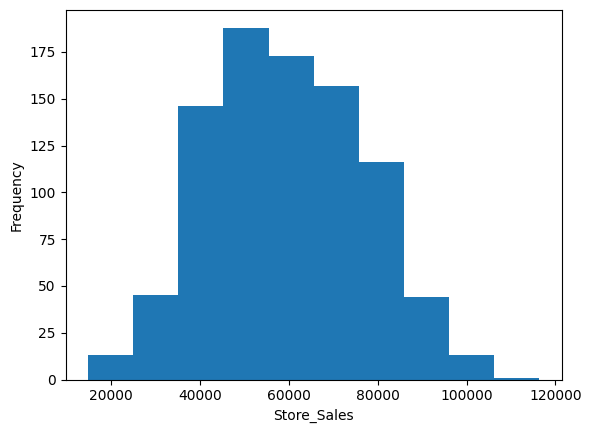

In [42]:
import matplotlib.pyplot as plt
pandas_data =data.toPandas()
plt.hist(pandas_data["Store_Sales"], bins=10)
plt.xlabel("Store_Sales")
plt.ylabel("Frequency")
plt.show()

In [43]:
data.write.parquet("output.parquet")